# Plots
This notebook contains the code to generate the plots for the final report.

In [6]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure utilities are accessible
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utilities import FINAL_OUTPUT_PATH, FINAL_LABELED_DATA_PATH

USE_VALIDATION_DATA = True

if USE_VALIDATION_DATA:
    data_path = FINAL_LABELED_DATA_PATH
else:
    data_path = FINAL_OUTPUT_PATH

if data_path.exists():
    df = pd.read_csv(data_path)
    print(f"Loaded data from {data_path}")
    print(f"Shape: {df.shape}")
else:
    print(f"Error: {data_path} not found. Please run the respective notebook first.")

Loaded data from /Users/gabriele/Documents/progetti_politecnico/chatgpt-at-work/chatgpt-at-work/data/validation/final_labeled_dataset.csv
Shape: (9, 21)


In [7]:
df.head(2)

,conversation,professions,tasks,job_title,selected_task,timestamp,country,state,hashed_ip,is_work_related_model,...,timestamp_local,interaction_type,task_match,label,lt1_reason,transferred_from,transferred_from_other,rationale,confidence,Job Zone
0,"[{'role': 'user', 'content': ""System: You are ...","['Interpreters and Translators', 'Public Relat...",Interpreters and Translators:Read written mate...,Interpreters and Translators,"Read written materials, such as legal document...",2024-11-04 01:14:03+00:00,NaN,NaN,738c8bec3e3b3fe22bedc4885fb26c230754e22747e031...,Yes,...,2024-11-04 05:44:03+04:30,consumer,good,LT1,low_stakes,translator,NaN,User requested translation of a short figure c...,high,4.0
1,"[{'role': 'user', 'content': 'You are a helpfu...","['Instructional Designers and Technologists', ...",Instructional Designers and Technologists:Deve...,Instructional Designers and Technologists,Develop instructional materials and products f...,2024-11-09 09:44:50+00:00,Belgium,Brussels Capital,5a527b1cb1af88eb990a824042cb105bb336ee03606f4f...,Yes,...,2024-11-09 10:44:50+01:00,consumer,good,LT1,unclear_user_role,other,instructional designer,User asks ChatGPT to generate a synthetic data...,medium,NaN


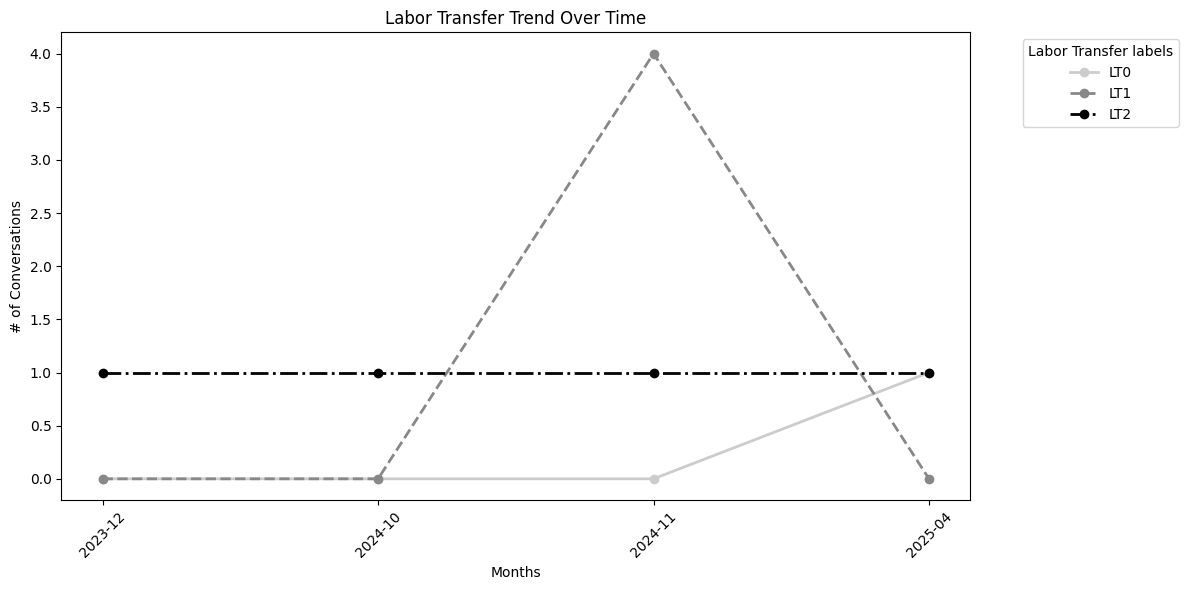

In [15]:
df["timestamp_local"] = df["timestamp_local"].apply(
    lambda x: pd.Timestamp(x).tz_localize(None)
)
df["year_month"] = df["timestamp_local"].dt.to_period("M")
label_col = "labor_transfer" if "labor_transfer" in df.columns else "label"

monthly_trend = df.groupby(["year_month", label_col]).size().unstack(fill_value=0)

colors = ["#CCCCCC", "#888888", "#000000"]
line_styles = ["-", "--", "-."]  # per distinguere meglio in b/n

plt.figure(figsize=(12, 6))

for col, color, style in zip(monthly_trend.columns, colors, line_styles):
    plt.plot(
        monthly_trend.index.astype(str),
        monthly_trend[col],
        marker="o",
        color=color,
        linestyle=style,
        label=col,
        linewidth=2,
    )

plt.title("Labor Transfer Trend Over Time")
plt.xlabel("Months")
plt.ylabel("# of Conversations")
plt.xticks(rotation=45)
plt.legend(title="Labor Transfer labels", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(visible=False)

plt.show()

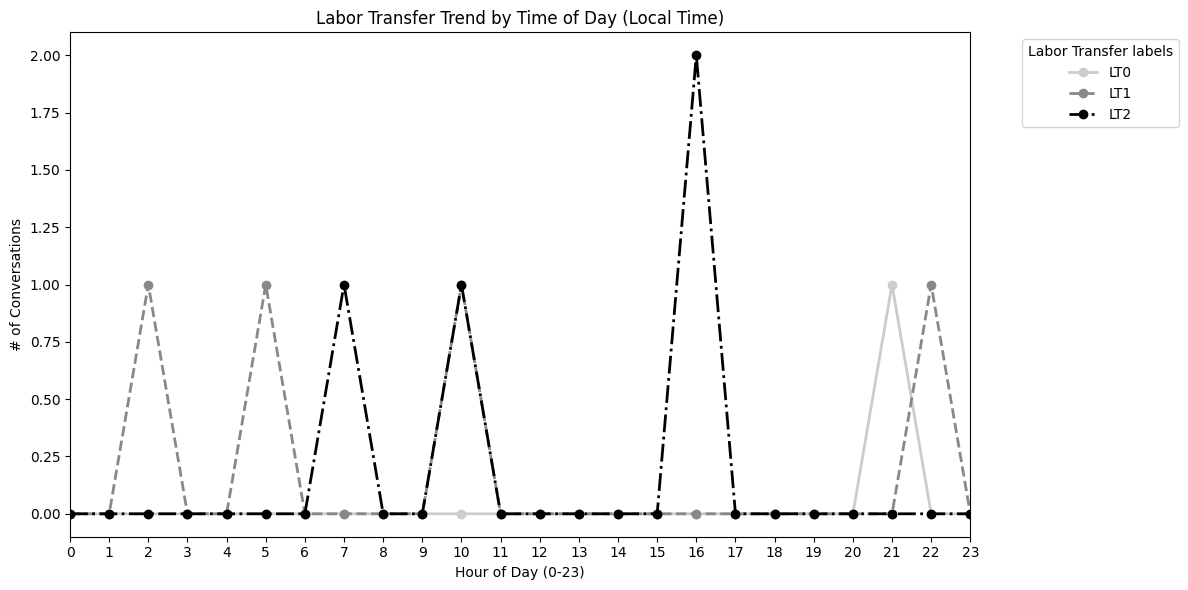

In [18]:
df["hour"] = df["timestamp_local"].dt.hour
hourly_trend = df.groupby(["hour", label_col]).size().unstack(fill_value=0)
hourly_trend = hourly_trend.reindex(range(24), fill_value=0)

plt.figure(figsize=(12, 6))
for col, color, style in zip(hourly_trend.columns, colors, line_styles):
    plt.plot(
        hourly_trend.index,
        hourly_trend[col],
        marker="o",
        color=color,
        linestyle=style,
        label=col,
        linewidth=2,
    )
plt.title("Labor Transfer Trend by Time of Day (Local Time)")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("# of Conversations")
plt.xlim(0, 23)
plt.xticks(range(0, 24))
plt.legend(title="Labor Transfer labels", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(visible=False)

plt.show()

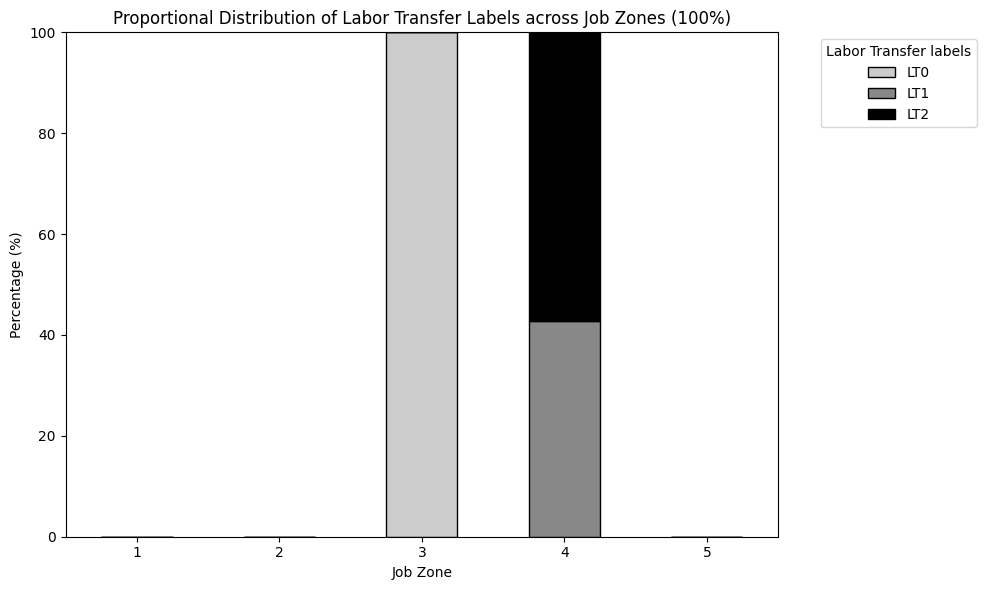

In [21]:
df_zones = df.dropna(subset=["Job Zone"]).copy()
zone_distribution = (
    df_zones.groupby(["Job Zone", label_col]).size().unstack(fill_value=0)
)
expected_zones = [1, 2, 3, 4, 5]
zone_distribution = zone_distribution.reindex(expected_zones, fill_value=0)
zone_distribution_pct = (
    zone_distribution.div(zone_distribution.sum(axis=1), axis=0).fillna(0) * 100
)
zone_distribution_pct.plot(
    kind="bar", stacked=True, figsize=(10, 6), color=colors, edgecolor="black"
)

plt.title("Proportional Distribution of Labor Transfer Labels across Job Zones (100%)")
plt.xlabel("Job Zone")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Labor Transfer labels", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()